# Read input along observed trajectories

In [1]:
vars = ["thetao","vxo","vyo","vxsi","vysi"]
cmems_id = 'cmems_mod_arc_phy_anfc_6km_detided_PT1H-i'
iceberg_id = 'iceberg2025w'
path_res = '/home/liaher/Documents/code/openberg_paper/results_iceberg2025w/'


## Functions and Imports

In [2]:
# Imports
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
# Functions for subsetting cmems data
def sample_cmems(
    ds,
    lats,
    lons,
    times,
    variables=None,
    method="opendrift",
):
    """
    Sample CMEMS variables at arbitrary locations.

    Parameters
    ----------
    ds : xr.Dataset

    lats, lons, times :
        scalar, array-like or xr.DataArray

    variables : list[str], optional

    method : str
        "opendrift"
            Linear interpolation in space/time with
            nearest-neighbour fallback for NaNs.

        "nearest"
            Nearest-neighbour lookup.

    Returns
    -------
    xr.Dataset
        Dimension: point
    """

    # --------------------------------------------------
    # helper
    # --------------------------------------------------

    def _as_1d(x):
        if isinstance(x, (xr.DataArray, xr.Variable)):
            x = x.values
        return np.atleast_1d(x)

    # --------------------------------------------------
    # inputs
    # --------------------------------------------------

    lats = _as_1d(lats)
    lons = _as_1d(lons)
    times = _as_1d(times)

    if not (len(lats) == len(lons) == len(times)):
        raise ValueError(
            "lats, lons and times must have identical lengths"
        )

    if variables is None:
        variables = list(ds.data_vars)

    ds = ds[variables]

    # --------------------------------------------------
    # coordinate names
    # --------------------------------------------------

    lat_name = (
        "latitude"
        if "latitude" in ds.coords
        else "lat"
    )

    lon_name = (
        "longitude"
        if "longitude" in ds.coords
        else "lon"
    )

    # --------------------------------------------------
    # use uppermost depth level if present
    # --------------------------------------------------

    depth_candidates = [
        "depth",
        "depthu",
        "depthv",
        "depthw",
        "lev",
        "level",
    ]

    for depth_name in depth_candidates:

        if depth_name in ds.dims:

            ds = ds.isel({depth_name: 0})

            break

    # --------------------------------------------------
    # longitude convention
    # --------------------------------------------------

    if float(ds[lon_name].min()) >= 0:
        lons = np.mod(lons, 360)
    else:
        lons = ((lons + 180) % 360) - 180

    # --------------------------------------------------
    # query coordinates
    # --------------------------------------------------

    query = xr.Dataset(
        coords={
            "point": np.arange(len(lats))
        }
    )

    query[lat_name] = ("point", lats)
    query[lon_name] = ("point", lons)
    query["time"] = ("point", times)

    # --------------------------------------------------
    # nearest neighbour lookup
    # --------------------------------------------------

    nearest = ds.sel(
        {
            lat_name: query[lat_name],
            lon_name: query[lon_name],
            "time": query["time"],
        },
        method="nearest",
    )

    if method == "nearest":

        result = nearest

    elif method == "opendrift":

        linear = ds.interp(
            {
                lat_name: query[lat_name],
                lon_name: query[lon_name],
                "time": query["time"],
            },
            method="linear",
        )

        # Fallback to nearest where interpolation fails
        result = linear.fillna(nearest)

    else:

        raise ValueError(
            "method must be 'nearest' or 'opendrift'"
        )

    # --------------------------------------------------
    # attach original query coordinates
    # --------------------------------------------------

    result = result.assign_coords(
        query_lat=("point", lats),
        query_lon=("point", lons),
        query_time=("point", times),
    )

    return result

In [4]:
# Functions for calculating speed, dir and components of iceberg
R_EARTH = 6371000.0  # m

def compute_drift_kinematics(
    ds,
    lat_name="lat",
    lon_name="lon",
    time_name="time",
):
    """
    Compute drift speed, direction, and velocity components.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing:
            lat(time)
            lon(time)
            time

    Returns
    -------
    xr.Dataset
        Original dataset with added variables:

        distance_m
        dt_s
        speed_ms
        u_ms
        v_ms
        direction_deg

    Notes
    -----
    Direction convention:

        0°   = North
        90°  = East
        180° = South
        270° = West
    """

    ds = ds.sortby(time_name).copy()

    lat = ds[lat_name]
    lon = ds[lon_name]

    lat1 = np.deg2rad(lat.shift({time_name: 1}))
    lon1 = np.deg2rad(lon.shift({time_name: 1}))

    lat2 = np.deg2rad(lat)
    lon2 = np.deg2rad(lon)

    # -------------------------------------------------
    # Time difference
    # -------------------------------------------------
    dt = (
        (ds[time_name] - ds[time_name].shift({time_name: 1}))
        / np.timedelta64(1, "s")
    )
    # -------------------------------------------------
    # Haversine distance
    # -------------------------------------------------
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R_EARTH * c

    # -------------------------------------------------
    # Local Cartesian displacement
    # -------------------------------------------------
    lat_mean = 0.5 * (lat1 + lat2)

    dx = R_EARTH * np.cos(lat_mean) * dlon
    dy = R_EARTH * dlat

    # -------------------------------------------------
    # Velocity components
    # -------------------------------------------------
    u = dx / dt
    v = dy / dt

    speed = np.sqrt(u**2 + v**2)

    # -------------------------------------------------
    # Bearing
    # -------------------------------------------------
    x = np.sin(dlon) * np.cos(lat2)

    y = (
        np.cos(lat1) * np.sin(lat2)
        - np.sin(lat1)
        * np.cos(lat2)
        * np.cos(dlon)
    )

    bearing = (
        np.degrees(np.arctan2(x, y)) + 360
    ) % 360

    # -------------------------------------------------
    # Store results
    # -------------------------------------------------
    ds["distance_m"] = distance
    ds["dt_s"] = dt

    ds["u_ms"] = u
    ds["v_ms"] = v

    ds["speed_ms"] = speed
    ds["direction_deg"] = bearing

    ds["distance_m"].attrs["units"] = "m"
    ds["dt_s"].attrs["units"] = "s"

    ds["u_ms"].attrs["units"] = "m s-1"
    ds["v_ms"].attrs["units"] = "m s-1"

    ds["speed_ms"].attrs["units"] = "m s-1"
    ds["direction_deg"].attrs["units"] = "degree"

    return ds

In [5]:
# Functions for plotting

def plot_scalar(vals,variable_name = '', title='',ax=None):
    #figure
    if ax is None:fig, ax = plt.subplots(figsize=(14, 4))
    else:fig = ax.figure
    #plot
    ax.plot(vals.time,vals,
        color="k",
        linewidth=1.5
        )
    ax.xaxis_date()
    ax.set_ylabel(variable_name)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    fig.savefig('%s/timeseries_%s.png'%(path_res,title.replace(' ','_')),dpi=200,transparent=True,bbox_inches='tight')

    return fig, ax

def plot_speed_uv(
    u,
    v,
    nth=10,
    arrow_length=None,
    ax=None,
    title=''
):
    """
    Plot speed time series with drift direction arrows.

    Parameters
    ----------
    speed : xr.DataArray
        Speed [m/s]

    u : xr.DataArray
        Eastward velocity [m/s]

    v : xr.DataArray
        Northward velocity [m/s]

    nth : int
        Plot every nth arrow.

    arrow_length : float
        Length of arrows in speed-axis units.
        If None an automatic value is chosen.

    Returns
    -------
    fig, ax
    """

    if ax is None:fig, ax = plt.subplots(figsize=(14, 4))
    else:fig = ax.figure

    speed = np.sqrt(u**2 + v**2)
    ax.plot(u.time,speed,
        color="k",
        linewidth=1.5,
        label='Drift Speed [m/s]'
    )

    track_dim = u.dims[0]

    mask = (
        np.isfinite(speed)
        & np.isfinite(u)
        & np.isfinite(v)
    )

    # speed_sub = (
    #     speed.where(mask)
    #     .isel({track_dim: slice(None, None, nth)})
    #     .dropna(track_dim)
    # )

    # u_sub = (
    #     u.where(mask)
    #     .isel({track_dim: slice(None, None, nth)})
    #     .dropna(track_dim)
    # )

    # v_sub = (
    #     v.where(mask)
    #     .isel({track_dim: slice(None, None, nth)})
    #     .dropna(track_dim)
    # )

    speed_clean = speed.where(mask)
    u_clean = u.where(mask)
    v_clean = v.where(mask)

    # Group index
    group = xr.DataArray(
        np.arange(speed.sizes[track_dim]) // nth,
        dims=track_dim
    )

    speed_sub = speed_clean.groupby(group).mean()
    u_sub = u_clean.groupby(group).mean()
    v_sub = v_clean.groupby(group).mean()

    if track_dim=='point':
        time_sub = (
        u.time
        .groupby(group)
        .map(lambda x: x.isel({track_dim: len(x)//2})))
    else: time_sub = (
        speed[track_dim]
        .groupby(group)
        .map(lambda x: x.isel({track_dim: len(x)//2})))

    # normalize velocity vectors
    mag = np.hypot(u_sub.values, v_sub.values)

    u_dir = u_sub.values / mag
    v_dir = v_sub.values / mag

    # angle from velocity vector
    theta = np.arctan2(v_dir, u_dir)

    arrow_length = 0.05

    dx = arrow_length * np.cos(theta)
    dy = arrow_length * np.sin(theta)

    x = mdates.date2num(time_sub.values)

    y = speed_sub.values + 0.1 * float(speed.max())

    ax.quiver(
        x,
        y,
        dx,
        dy,
        angles="uv",
        scale=1,
        width=0.003,
        pivot="middle",
        color="tab:red",
        label="Direction",
    )
    
    ax.xaxis_date()

    ax.set_ylabel("Speed (m/s)")
    ax.set_title("Speed and Direction %s"%title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.savefig('%s/timeseries_spd_dir_%s.png'%(path_res,title.replace(' ','_')),dpi=200,transparent=True,bbox_inches='tight')

    return fig, ax

In [6]:
# Functions for statistical analysis
def calc_stats1(u1,v1,u2,v2,stats_ds_in = False, periods = False):

    #create dataset
    if stats_ds_in==False: xr.Dataset() #stats_ds_in = xr.Dataset(coords=u1.coords)
    stats_ds_out = stats_ds_in.copy()

    #period to evaluate in 

    #correlation of speed
    tracker_speed = np.hypot(u1, v1)
    env_speed = np.hypot(u2, v2)
    stats_ds_out['corr_speed'] = xr.corr(
        tracker_speed,
        env_speed,
        dim="time").compute()
    
    #correlation of u,v components
    stats_ds_out['corr_u'] = xr.corr(
        u1,
        u2,
        dim="time").compute()

    stats_ds_out['corr_v'] = xr.corr(
        v1,
        v2,
        dim="time").compute()

    #correltion of vector
    z_tracker = u1 + 1j * v1
    z_water = u2 + 1j * v2
    num = np.nanmean(
        z_tracker * np.conj(z_water)
    )
    den = np.sqrt(
        np.nanmean(np.abs(z_tracker)**2)
        * np.nanmean(np.abs(z_water)**2)
    )
    vector_corr = num / den
    stats_ds_out['corr_vec_mag'] = abs(vector_corr) #Magnitude of vector correlation
    stats_ds_out['corr_vec_dir'] = np.angle(vector_corr, deg=True) #Average vector bias

    #Bias
    stats_ds_out['bias'] = (
        env_speed
        - tracker_speed
    ).mean("time").compute()

    #RMSE
    stats_ds_out['rmse'] = np.sqrt(
        (
            (env_speed - tracker_speed)**2
        ).mean("time")
    ).compute()
    #vector RMSE
    stats_ds_out['rmse_vec'] = np.sqrt(
        (
            (u1-u2)**2
            +
            (v1-v2)**2
        ).mean("time")
    ).compute()
    
    return stats_ds_out

In [7]:
def calc_stats2(
    u1,
    v1,
    u2,
    v2,
    periods=None,
    stats_ds_in=None,
    cmems_id="unknown",
    var_name = 'var_name'
):

    if periods is None:
        periods = {"all": slice(None)}

    stats_list = []

    for period_name, period in periods.items():
        ds = xr.Dataset()

        # subset
        uu1 = u1.sel(time=period)
        vv1 = v1.sel(time=period)
        uu2 = u2.sel(time=period)
        vv2 = v2.sel(time=period)

        tracker_speed = np.hypot(uu1, vv1)
        env_speed = np.hypot(uu2, vv2)

        # Pearson correlations
        ds["corr_speed"] = xr.corr(
            tracker_speed,
            env_speed,
            dim="time"
        ).compute()

        ds["corr_u"] = xr.corr(
            uu1,
            uu2,
            dim="time"
        ).compute()

        ds["corr_v"] = xr.corr(
            vv1,
            vv2,
            dim="time"
        ).compute()

        # Vector correlation
        z1 = uu1 + 1j * vv1
        z2 = uu2 + 1j * vv2

        num = (
            z1 * np.conj(z2)
        ).mean("time")

        den = np.sqrt(
            (np.abs(z1) ** 2).mean("time")
            * (np.abs(z2) ** 2).mean("time")
        )

        vector_corr = (num / den).compute()

        ds["corr_vec_mag"] = np.abs(vector_corr)
        ds["corr_vec_dir"] = np.angle(vector_corr, deg=True)

        # Bias
        ds["bias"] = (
            env_speed - tracker_speed
        ).mean("time").compute()

        # RMSE
        ds["rmse"] = np.sqrt(
            ((env_speed - tracker_speed) ** 2).mean("time")
        ).compute()

        # Vector RMSE
        ds["rmse_vec"] = np.sqrt(
            (
                (uu1 - uu2) ** 2
                + (vv1 - vv2) ** 2
            ).mean("time")
        ).compute()

        # Add period dimension
        ds = ds.expand_dims(period=[period_name],var=[var_name])

        stats_list.append(ds)

    # Combine periods
    ds_out = xr.concat(stats_list, dim="period")

    # Add cmems_id dimension
    ds_out = ds_out.expand_dims(cmems_id=[cmems_id])

    # Append to existing dataset if provided
    if stats_ds_in is not None:

        ds_out = xr.concat(
            [stats_ds_in, ds_out],
            dim="cmems_id"
        )

    return ds_out

In [8]:
def calc_stats(
    u1,
    v1,
    u2,
    v2,
    periods=None,
    stats_ds_in=None,
    cmems_id="unknown",
    var_name = 'var_name'
):
    if stats_ds_in is None:  stats_ds_out = xr.Dataset()
    else: stats_ds_out = stats_ds_in.copy()

    if periods is None:
        periods = {"all": slice(None)}

    stats_list = []

    for period_name, period in periods.items():

        # subset
        uu1 = u1.sel(time=period)
        vv1 = v1.sel(time=period)
        uu2 = u2.sel(time=period)
        vv2 = v2.sel(time=period)

        tracker_speed = np.hypot(uu1, vv1)
        env_speed = np.hypot(uu2, vv2)

        # Pearson correlations
        stats_ds_out["corr_speed"].loc[dict(period=period_name,cmems_id=cmems_id,var=var_name)] = xr.corr(
            tracker_speed,
            env_speed,
            dim="time"
        ).compute()

        stats_ds_out["corr_u"].loc[dict(period=period_name,cmems_id=cmems_id,var=var_name)] = xr.corr(
            uu1,
            uu2,
            dim="time"
        ).compute()

        stats_ds_out["corr_v"].loc[dict(period=period_name,cmems_id=cmems_id,var=var_name)] = xr.corr(
            vv1,
            vv2,
            dim="time"
        ).compute()

        # Vector correlation
        z1 = uu1 + 1j * vv1
        z2 = uu2 + 1j * vv2

        num = (
            z1 * np.conj(z2)
        ).mean("time")

        den = np.sqrt(
            (np.abs(z1) ** 2).mean("time")
            * (np.abs(z2) ** 2).mean("time")
        )

        vector_corr = (num / den).compute()

        stats_ds_out["corr_vec_mag"].loc[dict(period=period_name,cmems_id=cmems_id,var=var_name)] = np.abs(vector_corr)
        stats_ds_out["corr_vec_dir"].loc[dict(period=period_name,cmems_id=cmems_id,var=var_name)] = np.angle(vector_corr, deg=True)

        # Bias
        stats_ds_out["bias"].loc[dict(period=period_name,cmems_id=cmems_id,var=var_name)] = (
            env_speed - tracker_speed
        ).mean("time").compute()

        # RMSE
        stats_ds_out["rmse"].loc[dict(period=period_name,cmems_id=cmems_id,var=var_name)] = np.sqrt(
            ((env_speed - tracker_speed) ** 2).mean("time")
        ).compute()

        # Vector RMSE
        stats_ds_out["rmse_vec"].loc[dict(period=period_name,cmems_id=cmems_id,var=var_name)] = np.sqrt(
            (
                (uu1 - uu2) ** 2
                + (vv1 - vv2) ** 2
            ).mean("time")
        ).compute()


    return stats_ds_out

In [9]:
# --- Dictionary of available environmental input datasets ---
env_dict = {
    # --- Ocean ---
    'topaz4': 'cmems_mod_arc_phy_my_topaz4_P1D-m',
    'topaz4-ensemble':['https://thredds.met.no/thredds/dodsC/accibergt42/topaz4_be_mem0%s.ncml'%membnr for membnr in [('0'+str(memb)) 
                        if memb<10 else str(memb) for memb in range(1,11)]],
                        #find under:'https://thredds.met.no/thredds/catalog/accibergt42/catalog.html',
    'topaz5': 'cmems_mod_arc_phy_anfc_6km_detided_PT1H-i',
    'topaz5-ensemble': ['https://thredds.met.no/thredds/dodsC/accibergt5/topaz5_be_mem0%s.ncml'%membnr for membnr in [('0'+str(memb)) 
                        if memb<10 else str(memb) for memb in range(1,11)]],                      
                       #find under: https://thredds.met.no/thredds/catalog/accibergt5/catalog.html',
    'topaz6': 'https://thredds.met.no/thredds/dodsC/cmems/topaz6/dataset-topaz6-arc-15min-3km-be.ncml', 
    'topaz6-lowres': 'dataset-topaz6-arc-15min-3km-be',
    'glophyanfcH': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m', #Global anfc (mercator), hourly variables
    'glophyanfcD': 'cmems_mod_glo_phy_anfc_0.083deg_P1D-m', #daily variables (sea ice)
    'glorys': 'cmems_mod_glo_phy_my_0.083deg_P1D-m',
    # --- Sea ice ---
    'nextsimanfc':'cmems_mod_arc_phy_anfc_nextsim_hm',
    'nextsimre':'cmems_mod_arc_phy_my_nextsim_P1D-m',
    # --- Wave ---
    'arcmfcwam':'dataset-wam-arctic-1hr3km-be',
    'arcmfcwam_vars':{'id':"dataset-wam-arctic-1hr3km-be",'variables':["VHM0","VMDR","VSDX","VSDY"]},
    'arcmfcwamre':'cmems_mod_arc_wav_my_3km_PT1H-i',
    'mfwam':'cmems_mod_glo_wav_anfc_0.083deg_PT3H-i',
    'waverys':'cmems_mod_glo_wav_my_0.2deg_PT3H-i',
    # --- Wind ---
    'windglophyre':'cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H', #availability; 2007-2026
    'windglophynrt':'cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H', #availability: 2024-2026
    'era5':'', #Download
    'carra2': ''} #Download

## Iceberg data

In [10]:
# Read observations and subset
obs = xr.open_dataset('./merged_obs.nc')
obs_sub = obs.sel(iceberg=iceberg_id,trajectory_id=iceberg_id)
# print(obs_sub)

In [11]:
obs_sub_kin = compute_drift_kinematics(obs_sub)

In [12]:
# Extract data from obs (used to subset cmems data)
obstime = obs_sub.time[[0,-1]]
obslat = np.nanmin(obs_sub.lat),np.nanmax(obs_sub.lat)
obslon = np.nanmin(obs_sub.lon),np.nanmax(obs_sub.lon)

## Cmems data

In [ ]:
# Read cmems
if len(cmems_id)>0:
    import copernicusmarine as cm
    cmems = cm.open_dataset(
        dataset_id=cmems_id,
        variables=vars,
        minimum_longitude=obslon[0]-1,
        maximum_longitude=obslon[1]+1,
        minimum_latitude=obslat[0]-1,
        maximum_latitude=obslat[-1]+1,
        start_datetime=str(obstime[0].values),
        end_datetime=str(obstime[1].values),
    )
# or read other data sources
else: cmems = xr.open_dataset(link)
cmems = cmems.chunk({'latitude':-1,'longitude':-1})


INFO - 2026-07-10T10:40:56Z - Selected dataset version: "202311"
INFO - 2026-07-10T10:40:56Z - Selected dataset part: "default"


In [ ]:
# Extract cmems data along trajectory
cmems_sub = sample_cmems(cmems,
                       lons = obs_sub.lon,
                       lats = obs_sub.lat,
                       times = obs_sub.time,
                       variables = vars,
                       method = 'nearest').load()

In [ ]:

cmems_sub = cmems_sub.rename({"time": "time_orig"})
cmems_sub = cmems_sub.rename({"query_time": "time"})
cmems_sub = cmems_sub.swap_dims({"point": "time"})

## Visualisation

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Speed and Direction iceberg2025w'}, ylabel='Speed (m/s)'>)

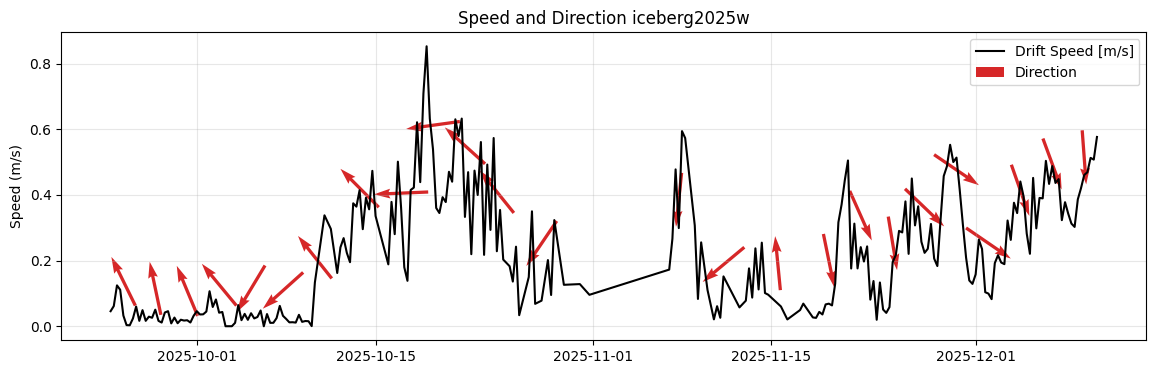

In [ ]:
#calc and plot iceberg obs
plot_speed_uv(obs_sub_kin.u_ms,obs_sub_kin.v_ms,title='iceberg2025w')

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Speed and Direction Topaz5 current aloong iceberg2025w'}, ylabel='Speed (m/s)'>)

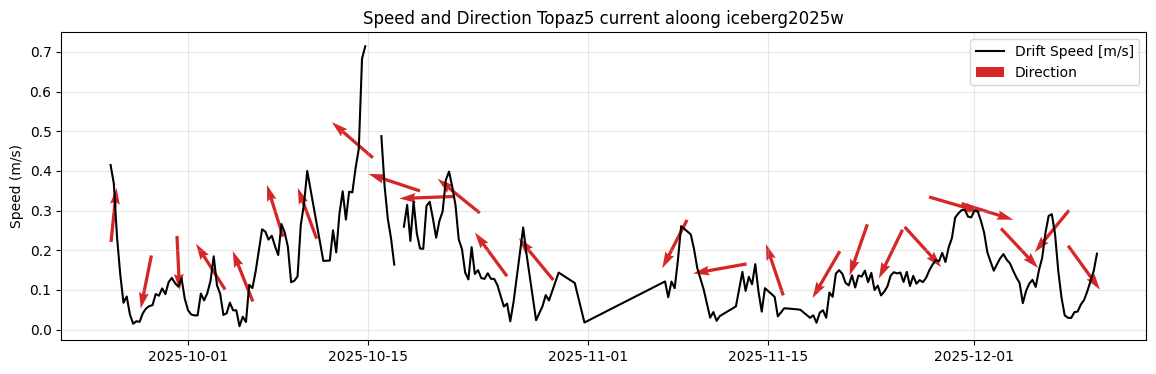

In [ ]:
#plot cmems data
plot_speed_uv(cmems_sub.vxo,cmems_sub.vyo,title='Topaz5 current along iceberg2025w')

## Statistics

In [ ]:
# stats_ds = xr.open_dataset('./stats_%s.nc'%iceberg_id)

In [ ]:
stats_ds = calc_stats(obs_sub_kin.u_ms,obs_sub_kin.v_ms, cmems_sub.vxo, cmems_sub.vyo,
                   periods={'full':slice(None),
                            'I':slice('2025-09-24','2025-10-27'),
                            'II':slice('2025-10-27','2025-11-23'),
                            'III':slice('2025-11-23','2025-12-11')},
                    cmems_id=cmems_id,
                #     stats_ds_in = stats_ds
                    )

In [ ]:
stats_ds

<xarray.Dataset> Size: 348B
Dimensions:       (cmems_id: 1, period: 4)
Coordinates:
  * cmems_id      (cmems_id) object 8B 'cmems_mod_arc_phy_anfc_6km_detided_PT...
  * period        (period) object 32B 'full' 'I' 'II' 'III'
    iceberg       <U13 52B 'iceberg2025w'
Data variables:
    corr_speed    (cmems_id, period) float64 32B 0.3958 0.4915 0.5712 0.02085
    corr_u        (cmems_id, period) float64 32B 0.6929 0.7172 0.2502 0.3158
    corr_v        (cmems_id, period) float64 32B 0.6726 0.4463 0.7214 0.3983
    corr_vec_mag  (cmems_id, period) float64 32B 0.6718 0.7202 0.7246 0.6394
    corr_vec_dir  (cmems_id, period) float64 32B 6.472 2.665 28.79 5.609
    bias          (cmems_id, period) float64 32B -0.06364 -0.006885 ... -0.1476
    rmse          (cmems_id, period) float64 32B 0.1839 0.1819 0.1351 0.2141
    rmse_vec      (cmems_id, period) float64 32B 0.2163 0.2014 0.1716 0.2628

In [ ]:
# stats_ds.to_netcdf('./stats_%s.nc'%iceberg_id)

## Loop through cmems

In [19]:
var_mapping = {
    'topaz5':{
            'x_sea_water_velocity':"vxo",
            'y_sea_water_velocity': "vyo",
            "sea_water_temperature": "thetao",
            "sea_ice_area_fraction": "siconc",
            "sea_ice_thickness": "sithick",
            "sea_ice_x_velocity": "vxsi",
            "sea_ice_y_velocity": "vysi"},
    'topaz4':{
            'x_sea_water_velocity':"vxo",
            'y_sea_water_velocity': "vyo",
            "sea_water_temperature": "thetao",
            "sea_ice_area_fraction": "siconc",
            "sea_ice_thickness": "sithick",
            "sea_ice_x_velocity": "vxsi",
            "sea_ice_y_velocity": "vysi"},
    'topaz6':{'x_sea_water_velocity':"vxo",
            'y_sea_water_velocity': "vyo",},
    'glophyanfcH':{
            'x_sea_water_velocity':"uo",
            'y_sea_water_velocity': "vo",
            "sea_water_temperature": "thetao",},
    'glophyanfcD':{
            "sea_ice_area_fraction": "siconc",
            "sea_ice_thickness": "sithick",
            "sea_ice_x_velocity": "usi",
            "sea_ice_y_velocity": "vsi"},
    'glorys':{
            'x_sea_water_velocity':"uo",
            'y_sea_water_velocity': "vo",
            "sea_water_temperature": "thetao",
            "sea_ice_area_fraction": "siconc",
            "sea_ice_thickness": "sithick",
            "sea_ice_x_velocity": "usi",
            "sea_ice_y_velocity": "vsi"},
    'nextsimre':{
            "sea_ice_area_fraction": "siconc",
            "sea_ice_thickness": "sithick",
            "sea_ice_x_velocity": "vxsi",
            "sea_ice_y_velocity": "vysi"},
    'nextsimanfc':{
            "sea_ice_area_fraction": "siconc",
            "sea_ice_thickness": "sithick",
            "sea_ice_x_velocity": "vxsi",
            "sea_ice_y_velocity": "vysi"},
    'windglophynrt':{
        'x_wind':'eastward_wind',
        'y_wind': 'northward_wind'   },
    'windglophyre':{
        'x_wind':'eastward_wind',
        'y_wind': 'northward_wind'   },
            # 'x_sea_water_velocity'
            # 'y_sea_water_velocity'
            # "sea_water_temperature"
            # "sea_water_salinity"
            # "sea_ice_area_fraction"
            # "sea_ice_thickness"
            # "sea_ice_x_velocity"
            # "sea_ice_y_velocity"
            # 'x_wind'
            # 'y_wind'
            # "sea_surface_wave_significant_height"
            # "sea_surface_wave_from_direction"
            # "sea_surface_wave_stokes_drift_x_velocity" 
            # "sea_surface_wave_stokes_drift_y_velocity"
            # "sea_floor_depth_below_sea_level"
            # 'sea_surface_height'
            
            }

In [22]:
cmems_names = ['windglophynrt',]
# vars = np.unique([var_mapping[cmems_name] for cmems_name in cmems_names])
cmems_l = [env_dict[name] for name in cmems_names]
link = ''
period_dict = {'full':slice(None),
                                'I':slice('2025-09-24','2025-10-27'),
                                'II':slice('2025-10-27','2025-11-23'),
                                'III':slice('2025-11-23','2025-12-11')}
print(iceberg_id)

iceberg2025w


In [42]:
save_env
save_env['x_wind'] = (('time', 'cmems_id'), np.full((250,5),np.nan)) #example for adding variable later
save_env['y_wind'] = (('time', 'cmems_id'), np.full((250,5),np.nan)) #example for adding variable later


cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H windglophynrt ['eastward_wind', 'northward_wind']
x_wind
y_wind
Stats calculated
Data loaded and saved


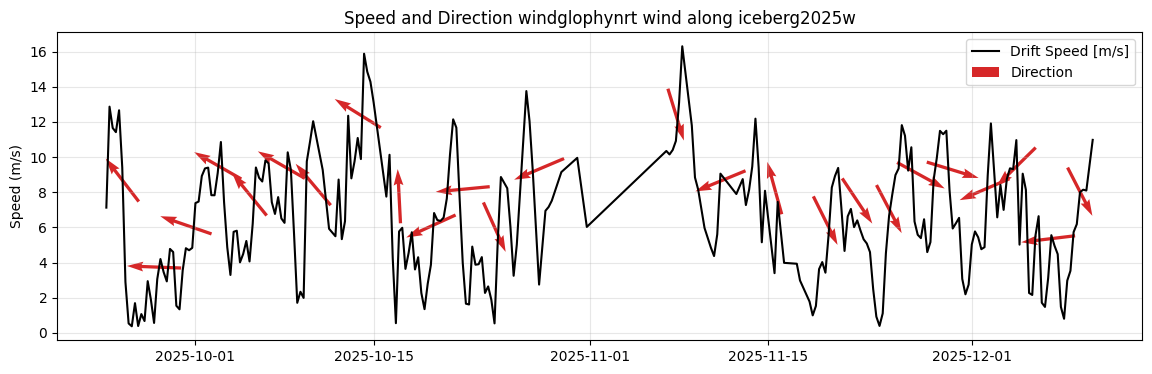

In [43]:
# # create or load dict to save env in
# try: 
#     with xr.open_dataset('%s/%s_env_along_obs.nc'%(path_res,iceberg_id)) as ds:
#         save_env = ds.load()
# except:
#     save_env = xr.Dataset(
#         coords={
#             "time":  obs_sub.time.data,
#             "iceberg": iceberg_id,
#             "cmems_id": cmems_l,
#         },
#         data_vars={
#         v: (
#         ("time", "cmems_id"),
#         np.full((len(obs_sub.time), len(cmems_l)), np.nan)
#         )    for v in np.unique([vv for k,v in var_mapping.items() for vv in v.keys()])
# }
#     )

# # load existing stats
# try: 
#     with xr.open_dataset('%s/%s_stats.nc'%(path_res,iceberg_id)) as ds:
#         stats_ds_save = ds.load()
# except: 
#     stats_ds_save = xr.Dataset(
#         coords={
#             "cmems_id": cmems_l,
#             "period": list(period_dict.keys()),
#             "iceberg": iceberg_id,
#             "var": ['y_sea_water_velocity','sea_ice_y_velocity','y_wind']
#         },
#         data_vars={v:(('cmems_id','period','var'),
#                         np.full((len(cmems_l),len(period_dict),3),np.nan))
#                         for v in ['corr_speed','corr_u','corr_v','rmse','bias','rmse_vec','corr_vec_mag','corr_vec_dir']}
#     )
# #save_env['y_wind'] = (('time', 'cmems_id'), np.full((250,5),np.nan)) #example for adding variable later
# print('Datesets loaded or created')

for cmems_id in cmems_l:
    cmems_name = [k for k, v in env_dict.items() if v == cmems_id][0]
    vars = var_mapping[cmems_name].keys()
    vars_cmems = [var_mapping[cmems_name][v] for v in vars if v in var_mapping[cmems_name]]
    print(cmems_id, cmems_name, vars_cmems)
    # # Read cmems
    # try:
    #     import copernicusmarine as cm
    #     cmems = cm.open_dataset(
    #         dataset_id=cmems_id,
    #         variables=vars_cmems,
    #         minimum_longitude=obslon[0]-1,
    #         maximum_longitude=obslon[1]+1,
    #         minimum_latitude=obslat[0]-1,
    #         maximum_latitude=obslat[-1]+1,
    #         start_datetime=str(obstime[0].values),
    #         end_datetime=str(obstime[1].values),
    #     )
    # # or read other data sources
    # except: cmems = xr.open_dataset(cmems_id)
    # cmems = cmems.chunk({'latitude':-1,'longitude':-1})

    # # Extract cmems data along trajectory
    # cmems_sub = sample_cmems(cmems,
    #                     lons = obs_sub.lon,
    #                     lats = obs_sub.lat,
    #                     times = obs_sub.time,
    #                     variables = vars_cmems,
    #                     method = 'nearest').load()

    # cmems_sub = cmems_sub.rename({"time": "time_orig"})
    # cmems_sub = cmems_sub.rename({"query_time": "time"})
    # cmems_sub = cmems_sub.swap_dims({"point": "time"})

    for v in vars:
        print(v)
        #save
        if cmems_id not in save_env.cmems_id: 
            save_env = save_env.reindex(cmems_id=save_env.cmems_id.values.tolist()+[cmems_id])
        save_env[v].loc[dict(cmems_id=cmems_id)] = cmems_sub[var_mapping[cmems_name][v]].data
        #plot cmems data
        if 'y_' in v: 
            if cmems_id not in stats_ds_save.cmems_id:
                stats_ds_save = stats_ds_save.reindex(cmems_id=stats_ds_save.cmems_id.values.tolist()+[cmems_id])
            plot_speed_uv(save_env[v.replace('y_','x_')].loc[dict(cmems_id=cmems_id)], save_env[v].loc[dict(cmems_id=cmems_id)],
                          title='%s %s along %s'%(cmems_name,v.replace('y_',''),iceberg_id))
            stats_ds_save = calc_stats(obs_sub_kin.u_ms,obs_sub_kin.v_ms, 
                        save_env[v.replace('y_','x_')].sel(cmems_id=cmems_id), save_env[v].sel(cmems_id=cmems_id),
                        periods=period_dict,
                        cmems_id=cmems_id,
                        stats_ds_in = stats_ds_save,
                        var_name=v
                        )
            print('Stats calculated')
        elif 'x' in v: continue #already covered under 'y'
        else: plot_scalar(save_env[v].loc[dict(cmems_id=cmems_id)],variable_name=v,title='%s %s along %s'%(cmems_name,v,iceberg_id))
    print('Data loaded and saved')


stats_ds_save.to_netcdf('%s/%s_stats.nc'%(path_res,iceberg_id),"w")
save_env.to_netcdf('%s/%s_env_along_obs.nc'%(path_res,iceberg_id),"w")

In [44]:
# stats_ds_save = xr.open_dataset('%s/%s_stats.nc'%(path_res,iceberg_id))
stats_ds_save.corr_speed.sel(var='y_wind').data

array([[       nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan],
       [0.17499996, 0.04582602, 0.59412162, 0.31014418]])

Plot multiple cmems_id in one timeseries plot (scalar for now)

In [4]:
iceberg_id='iceberg2025w'
save_env = xr.open_dataset('./%s_env_along_obs.nc'%iceberg_id)


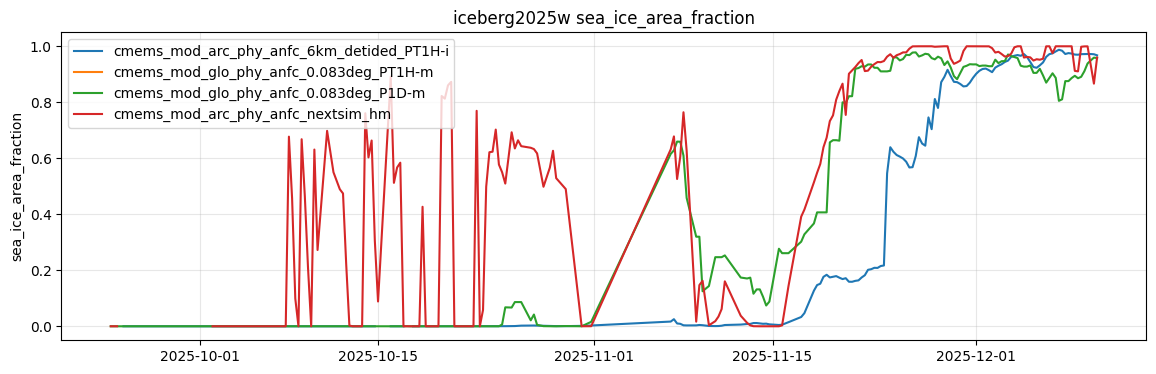

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'iceberg2025w sea_ice_area_fraction'}, ylabel='sea_ice_area_fraction'>)

In [21]:
import seaborn as sns
def plot_scalar_mult(vals,dim_col='trajectory_id',variable_name = '', title='',palette_opt=None,ax=None):
    #figure
    if ax is None:fig, ax = plt.subplots(figsize=(14, 4))
    else:fig = ax.figure
    for d in vals[dim_col]:
        #plot
        ax.plot(vals.time,vals.loc[{dim_col:d}],
            linewidth=1.5,
            label=d.values.astype(str)
            )
    ax.xaxis_date()
    ax.set_ylabel(variable_name)
    ax.set_title(title if len(title)>0 else '%s %s'%(iceberg_id,variable_name))
    ax.grid(True, alpha=0.3)
    plt.legend()
    fig.savefig('%s/%s_timeseries_%s_mult.png'%(path_res,iceberg_id,variable_name),dpi=200,transparent=True,bbox_inches='tight')
    plt.show()
    return fig, ax

plot_scalar_mult(save_env.sea_ice_area_fraction,dim_col='cmems_id',
                 variable_name='sea_ice_area_fraction')